# 02 — Exploratory Data Analysis

## Purpose
This notebook explores the leads and monthly metrics datasets 
visually to identify patterns, trends, and anomalies that 
support the three core business questions.

## Charts produced
1. Lead volume over time — monthly trend
2. Conversion rate by channel — horizontal bar chart
3. Days in funnel distribution — boxplot by stage
4. Revenue trend — monthly line with 3-month moving average

## Outputs
All charts are saved to /reports/ for use in the README 
and Notion portfolio page.

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Global style settings
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Load cleaned datasets
leads = pd.read_csv('../data/processed/leads_clean.csv')
metrics = pd.read_csv('../data/processed/monthly_metrics.csv')

# Parse dates
leads['entry_date'] = pd.to_datetime(leads['entry_date'])
leads['month'] = leads['entry_date'].dt.to_period('M')
metrics['month'] = pd.to_datetime(metrics['month'])

print("Data loaded successfully")
print(f"leads: {leads.shape} | metrics: {metrics.shape}")

Data loaded successfully
leads: (380, 10) | metrics: (24, 10)


### Chart 1. Lead volume over time

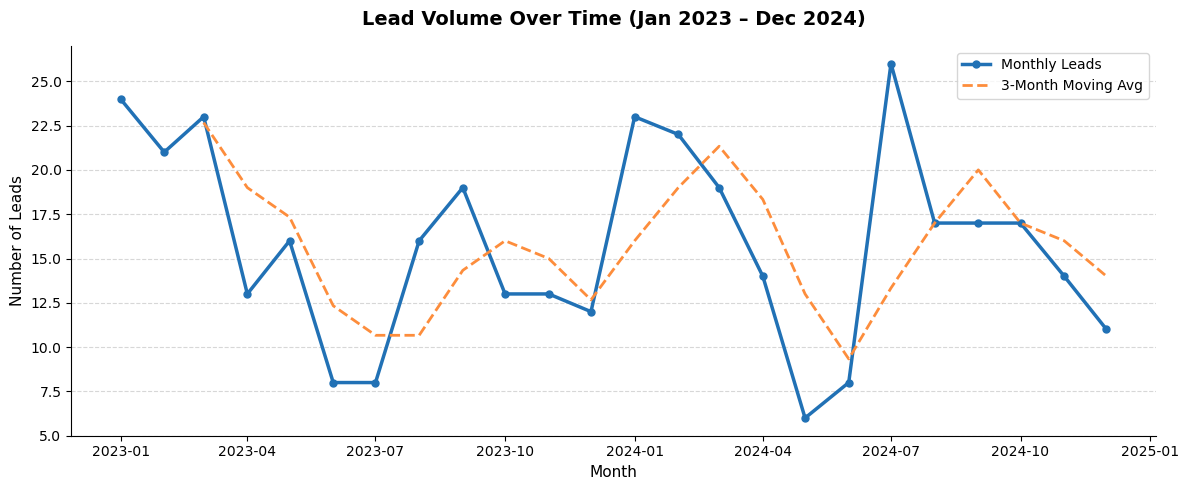

In [92]:
# Aggregate leads by month
monthly_leads = (leads.groupby('month').size().reset_index(name='total_leads'))
monthly_leads['month'] = monthly_leads['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(monthly_leads['month'], monthly_leads['total_leads'], color='#2171b5', linewidth=2.5, marker='o', markersize=5, label='Monthly Leads')

# Add 3-month moving average
monthly_leads['ma3'] = monthly_leads['total_leads'].rolling(3).mean()
ax.plot(monthly_leads['month'], monthly_leads['ma3'], color='#fd8d3c', linewidth=2, linestyle='--', label='3-Month Moving Avg')

ax.set_title('Lead Volume Over Time (Jan 2023 – Dec 2024)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Number of Leads', fontsize=11)
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../reports/lead_volume_trend.png', dpi=150, 
            bbox_inches='tight')
plt.show()

### Chart 2.  Conversion rate by channel

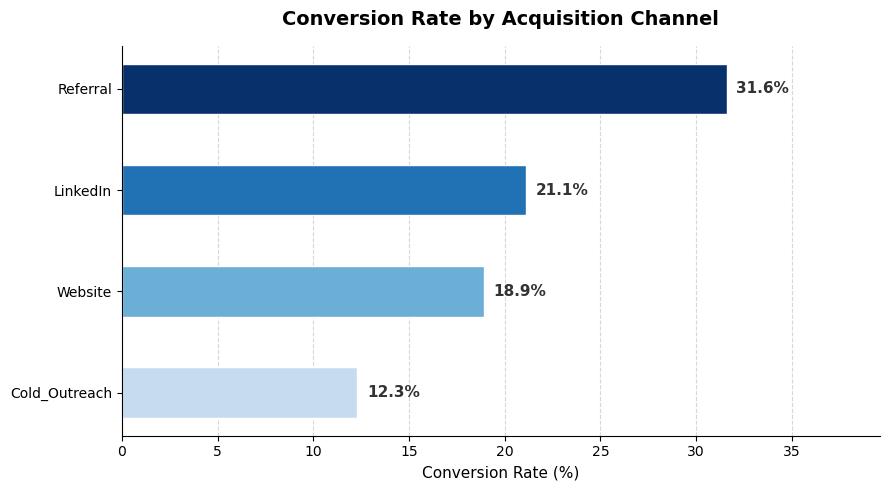

In [93]:
channel_conv = (
    leads.groupby('channel')['converted'].mean().mul(100).round(1).sort_values().reset_index())
channel_conv.columns = ['channel', 'conversion_rate_pct']

colors = ['#c6dbef', '#6baed6', '#2171b5', '#08306b']

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(channel_conv['channel'],channel_conv['conversion_rate_pct'], color=colors, height=0.5, edgecolor='white')

# Add value labels
for bar, val in zip(bars, channel_conv['conversion_rate_pct']): ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f"{val}%", va='center', fontsize=11, fontweight='bold', color='#333333')

ax.set_title('Conversion Rate by Acquisition Channel',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Conversion Rate (%)', fontsize=11)
ax.set_ylabel('')
ax.set_xlim(0, channel_conv['conversion_rate_pct'].max() + 8)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../reports/conversion_by_channel.png', dpi=150,
            bbox_inches='tight')
plt.show()


### Chart 3. Days in funnel by stage

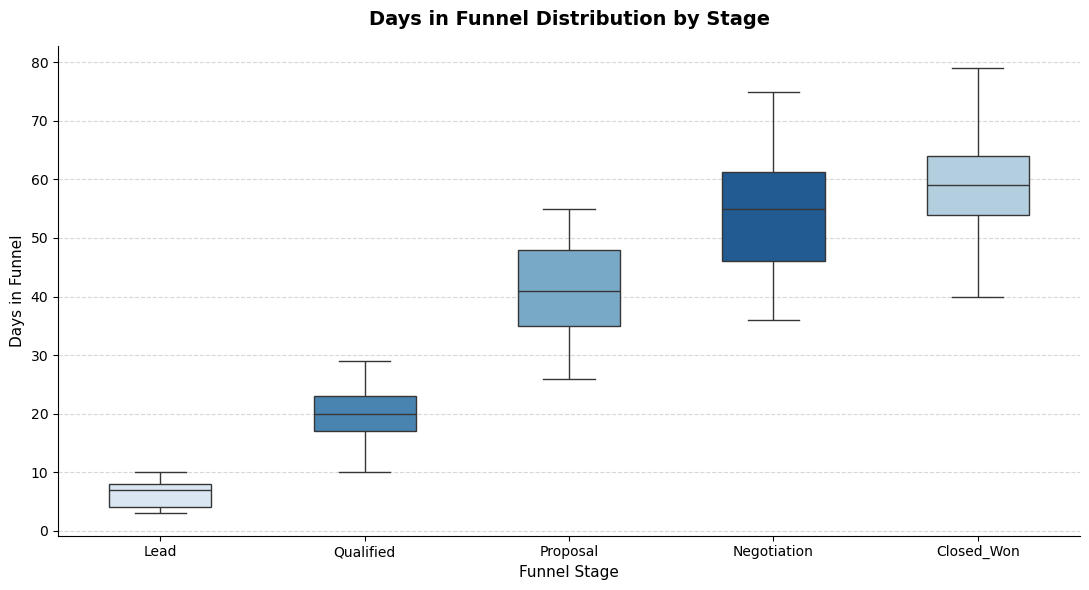

In [94]:
stage_order = ['Lead', 'Qualified', 'Proposal', 'Negotiation', 'Closed_Won']

leads_filtered = leads[leads['stage_reached'].isin(stage_order)].copy()

fig, ax = plt.subplots(figsize=(11, 6))

sns.boxplot(data=leads_filtered, x='stage_reached', y='days_in_funnel', order=stage_order, hue='stage_reached', palette='Blues', legend=False, width=0.5, ax=ax)

ax.set_title('Days in Funnel Distribution by Stage',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Funnel Stage', fontsize=11)
ax.set_ylabel('Days in Funnel', fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../reports/days_in_funnel_boxplot.png', dpi=150,
            bbox_inches='tight')
plt.show()


### Chart 4. Revenue trend 

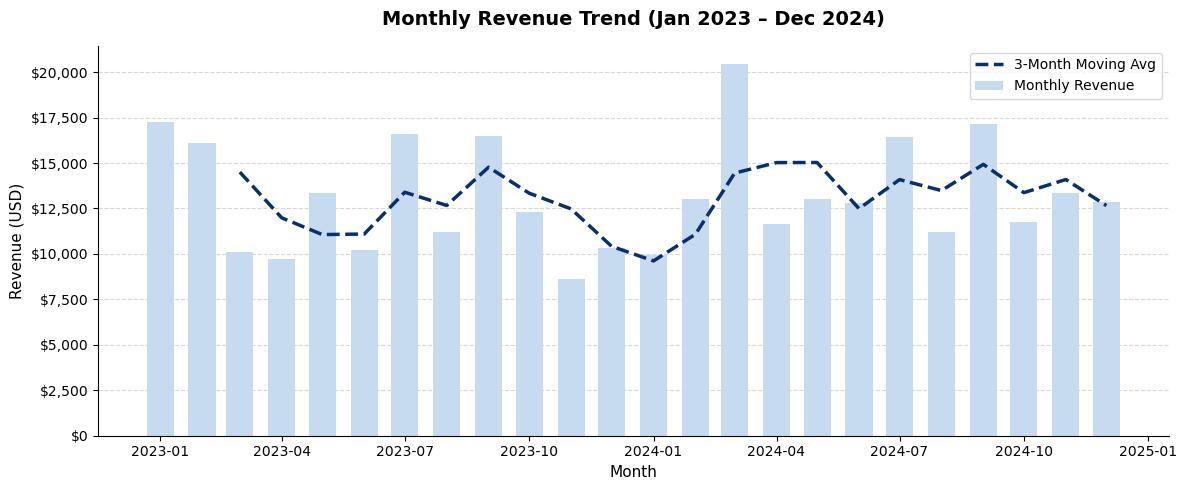

In [95]:
metrics['ma3_revenue'] = metrics['revenue'].rolling(3).mean()

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(metrics['month'], metrics['revenue'], color='#c6dbef', width=20, label='Monthly Revenue')

ax.plot(metrics['month'], metrics['ma3_revenue'], color='#08306b', linewidth=2.5, linestyle='--', label='3-Month Moving Avg')

ax.set_title('Monthly Revenue Trend (Jan 2023 – Dec 2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue (USD)', fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
)
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../reports/revenue_trend.png', dpi=150,
            bbox_inches='tight')
plt.show()


## EDA: Key Visual Findings

### Chart 1. Lead Volume Trend
- Lead volume shows a consistent seasonal dip in Apr–Jun across both years, bottoming at 6 leads in May 2024
- The 3-month moving average shows a mild overall decline from around 22 leads/month in early 2023 to around 14 in late 2024
- Despite lower volume, revenue held stable in 2024 suggesting improved lead quality and conversion efficiency

### Chart 2. Conversion Rate by Channel
-  Referral is the strongest channel at 31.6% — nearly 2.6x higher than Cold Outreach (12.3%)
- The ~19 point gap between best and worst channel signals a significant difference in lead quality at entry
- Cold Outreach delivers the lowest conversion rate and lowest avg deal value ($3,686) — making it the least efficient channel by both volume and quality metrics
- Key recommendation: reallocate Cold Outreach resources toward referral program development and LinkedIn content strategy

### Chart 3. Days in Funnel by Stage
- Negotiation shows the widest interquartile range (~14 days) indicating high variability and inconsistent process execution at the most critical stage
- Closed_Won has the longest whiskers (40–79 days) — fast-closing deals finish in ~40 days while slower ones take nearly 80, suggesting an opportunity to identify and replicate fast-close patterns
- Lead stage is the most consistent (3–10 days) — leads either advance quickly or stall immediately with little ambiguity

### Chart 4. Revenue Trend
- H2 2024 shows the most stable revenue performance of the entire period — the 3-month moving average holds between $12,500–$15,000 without the sharp dips seen in 2023
- The March 2024 peak ($20,425) is the single highest revenue month in the dataset, coinciding with the highest lead volume month of 2024 (20 new leads)
- Despite lead volume softening in late 2024, revenue remained stable — the moving average confirms this is a structural improvement, not a lucky month
- Key insight: the firm achieved revenue stability in 2024 through better conversion efficiency rather than higher lead volume